In [1]:
setwd("/DATA/User/liqian7/pienapple/24AS_fig_add/09S4_update/")

In [3]:
library(hdf5r)
library(Seurat)
library(ggplot2)
library(stringr)
#####feature plot
library(Seurat)
library(ggplot2)
library(cowplot)
library(dplyr)
library(tidyr)
library(stringr)
library(viridis)
library(reshape2)
library(patchwork)
library(ggplot2)
library(ggridges)
library(RColorBrewer)
library(scales)
library(stringr)
library(Seurat)
library("FactoMineR")
library(ggplot2)
library(vegan)
library(ape)
library(phyloseq)
library(ggalt)
library(microeco)
library(jsd)
library("factoextra")
library(Seurat)
library(stringr)
library(ggplot2)
library(pheatmap)
library(dplyr)

In [4]:
gs <- read.csv("gs.csv")

In [5]:
cols1=c('normal'="#8CE4FF",'early'="#007F73",'median'="#FFC700",'late'="#f16c23")
cols2= c('Carotid artery plaque'="#A6FF96",'Common iliac artery'="#F8FF95",'Abdominal aorta'="#BC7AF9",'Coronary artery'="#E67E22",'Thoracic aorta'="#932F67",'Lower limb artery occlusion'="#F6FF99")
cols3= c('NCR1'="#40B7AD",'NCR2'="#FAA419",'this paper'="#df65b0")
cols5= c('stage1'="#a7d3d4",'stage2'="#009b9e",'stage3'="#e4c1d9",'stage4'="#c75dab")
cols1 <- c('normal'='#63C8FF','early'='#4DFFBE','median'='#FDFFB8','late'='#FF2DD1')

In [11]:
sp <- readRDS("let_ALL_save1.RDS")###pseudobulk data
sp <- NormalizeData(sp)
m <- sp@meta.data
exp <- as.data.frame(sp@assays$RNA@data)

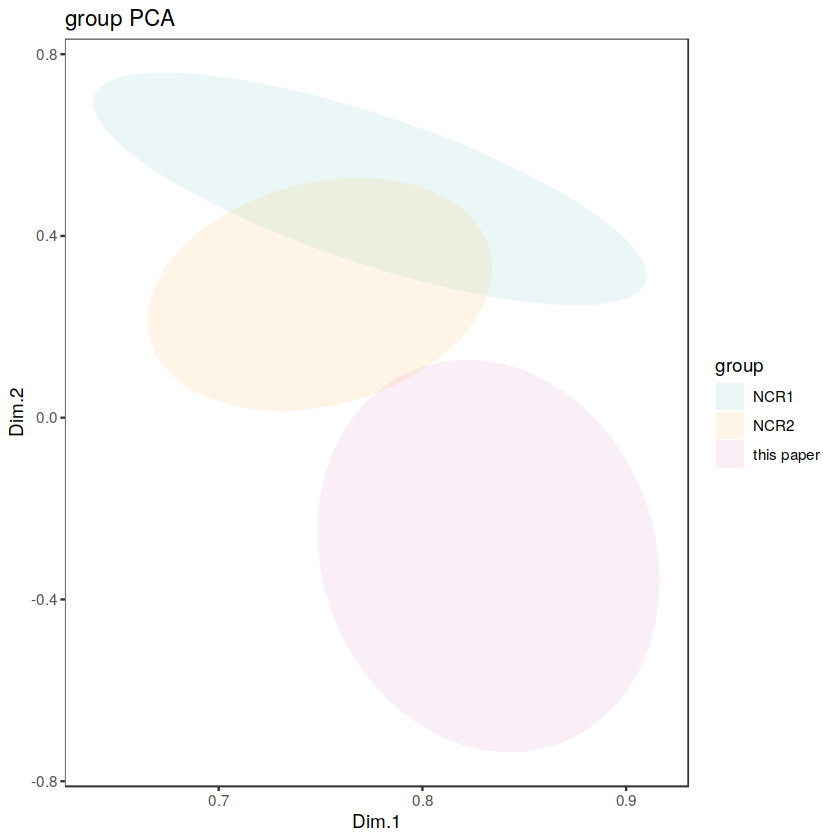

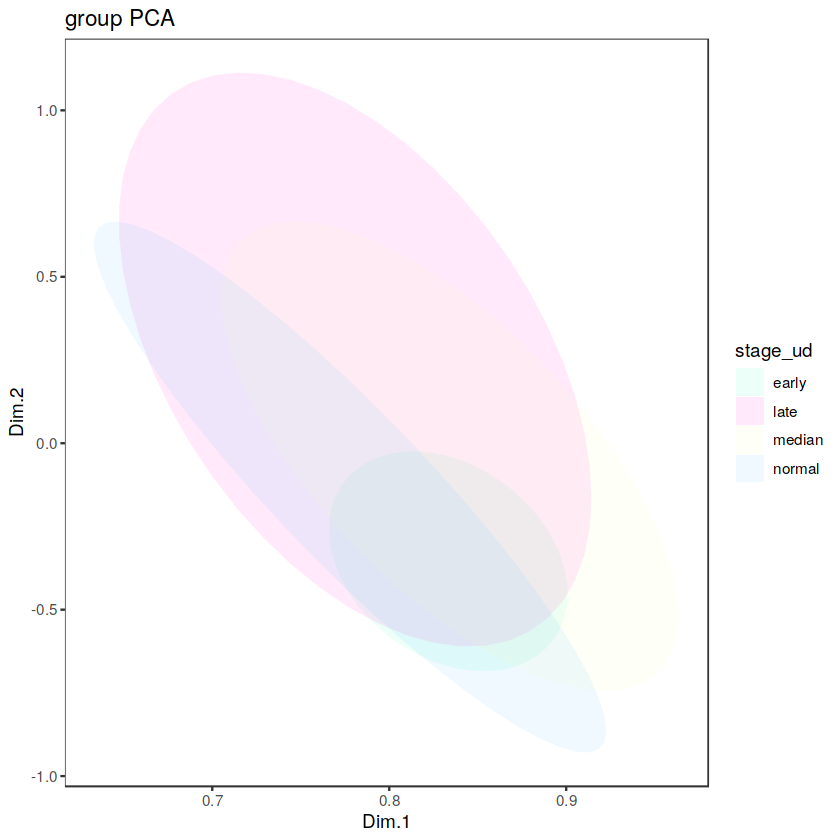

In [12]:
exprSet = exp[names(sort(apply(exp, 1, mad),decreasing = T)[1:3000]),]
res.pca <-PCA(exprSet, graph = FALSE)
eig.val <- get_eigenvalue(res.pca)
var <- get_pca_var(res.pca)
df1 <- merge(var$coord,m,all = TRUE,by = 0)
rownames(df1) <- df1$Row.names
df1 <- df1[,-1]

p <- ggplot(data = df1[which(df1$sample=="save"),], aes(Dim.1,Dim.2))+
geom_point(size=4.5,aes(color=group))+ 
scale_color_manual(values = cols3)+
  theme_bw()+theme(panel.grid = element_blank())+
  stat_ellipse(data = df1,geom="polygon",level = 0.9,alpha = 0.1,linetype=1,aes(fill=group))+scale_fill_manual(values = cols3)+
  labs(title= "group PCA")
p <- ggplot(data = df1[which(df1$sample=="save"),], aes(Dim.1,Dim.2))+
geom_point(size=4.5,aes(color=stage_ud))+ 
scale_color_manual(values = cols1)+
  theme_bw()+theme(panel.grid = element_blank())+
  stat_ellipse(data = df1,geom="polygon",level = 0.9,alpha = 0.1,linetype=1,aes(fill=stage_ud))+scale_fill_manual(values = cols1)+
  labs(title= "group PCA")

In [230]:
table(df1$sample)


filter   save 
    10     71 

In [10]:
m1 <- subset(m,select = c("sample","stage_ud","adventitia","tissue","stage_ann1"))
colnames(m1) <- c("sample_filter","stage_ud","adventitia","tissue","stage_ann1")

In [11]:
df <- readRDS("pca_df.RDS")####base plauqe gene
df1 <- merge(df,m1,all = TRUE,by = 0)
rownames(df1) <- df1$Row.names
df1 <- df1[,-1]
head(df1)

,Dim.1,Dim.2,Dim.3,Dim.4,Dim.5,stage_1,tissue1,group,stage_ann,stage_ann_peaks,sample_filter,stage_ud,adventitia,tissue,stage_ann1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
A01189E1_1,0.9242415,-0.3197024,-0.04960970,0.03726952,0.053304756,late,carotid artery,NCR1,stage4,stage4,A01189E1_1,late,none,Carotid artery,stage4
A01189E3_1,0.8945228,-0.3508904,-0.03897795,-0.04322784,0.115055783,late,carotid artery,NCR1,stage4,stage4,A01189E3_1,late,none,Carotid artery,stage4
A05862E3_1,0.8333125,0.3496301,0.34373101,0.17430218,0.006013618,late,carotid artery,this paper,stage1,stage1,NA,NA,NA,NA,NA
A05862E3_2,0.7797686,0.2034989,0.43498587,0.30973186,-0.031981444,late,carotid artery,this paper,stage1,stage2,NA,NA,NA,NA,NA
A05872E5_1,0.9224594,-0.1839171,0.20144491,0.16430683,-0.068026340,late,carotid artery,this paper,stage3,stage3,A05872E5_1,late,none,Carotid artery,stage2
A05872E5_2,0.8941868,-0.2521891,0.14526378,0.28901313,-0.090060525,late,carotid artery,this paper,stage4,stage3,A05872E5_2,late,none,Carotid artery,stage3


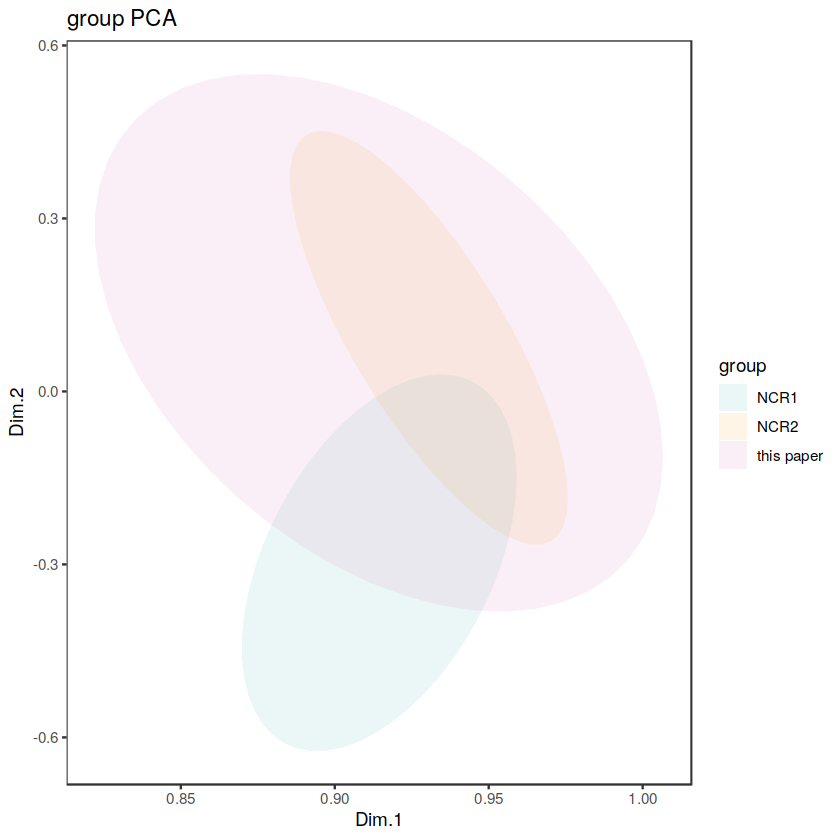

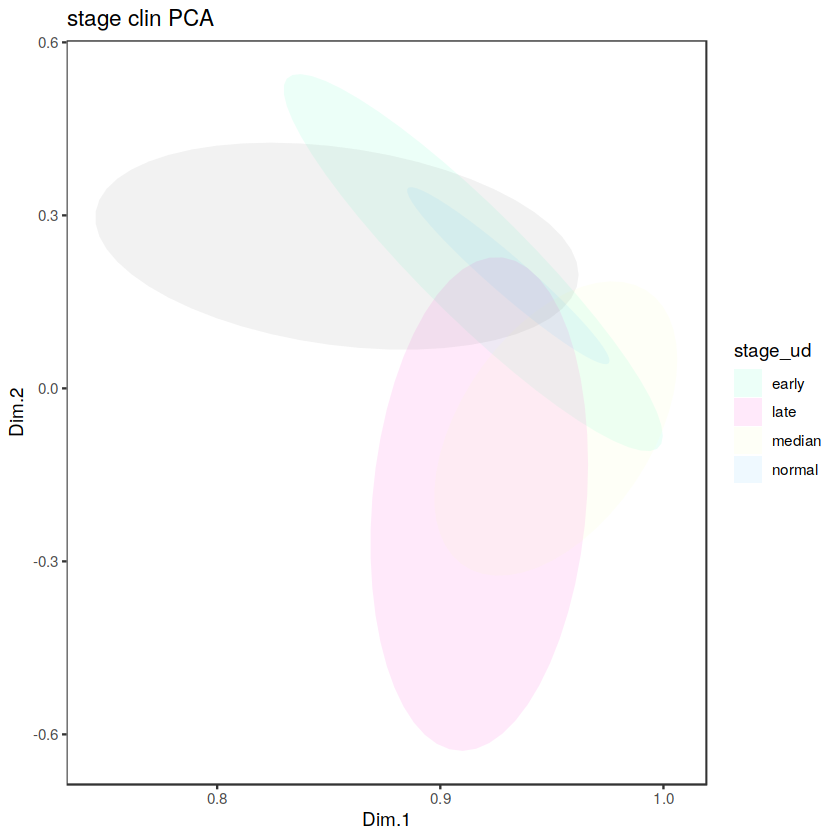

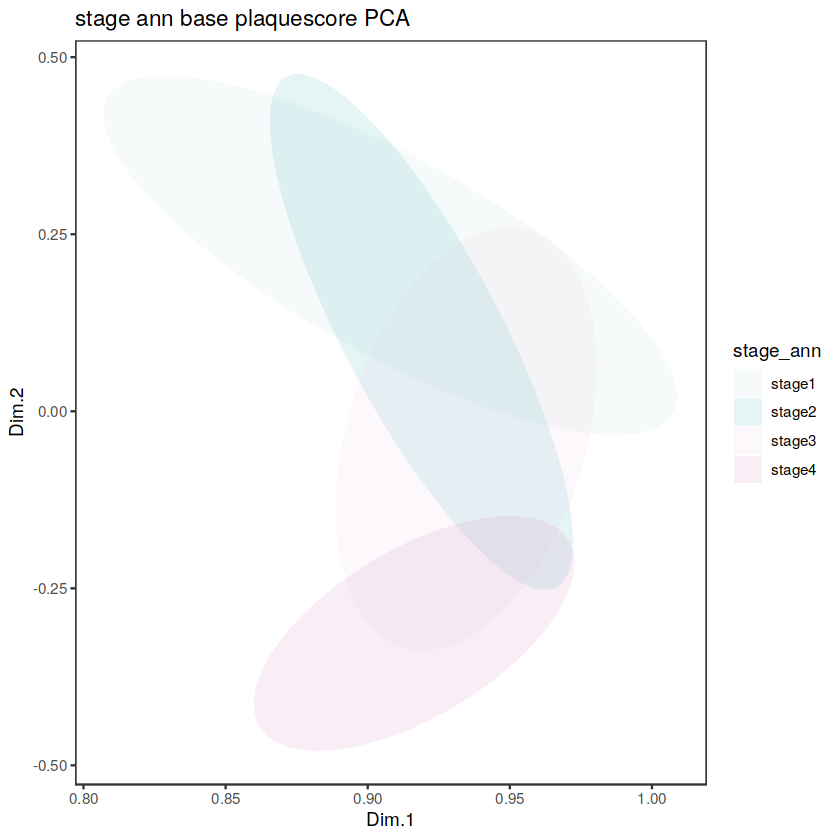

In [15]:
p <- ggplot(data = df1[which(df1$sample_filter=="save"),], aes(Dim.1,Dim.2))+
geom_point(size=4.5,aes(color=group))+ 
scale_color_manual(values = cols3)+
  theme_bw()+theme(panel.grid = element_blank())+
  stat_ellipse(data = df1,geom="polygon",level = 0.9,alpha = 0.1,linetype=1,aes(fill=group))+scale_fill_manual(values = cols3)+
  labs(title= "group PCA")
p
ggsave("S4E_PCA_plaque_score_group.pdf",p,width = 6,height = 5.5)
p <- ggplot(data = df1[which(df1$sample=="save"),], aes(Dim.1,Dim.2))+
geom_point(size=4.5,aes(color=stage_ud))+ 
scale_color_manual(values = cols1)+
  theme_bw()+theme(panel.grid = element_blank())+
  stat_ellipse(data = df1,geom="polygon",level = 0.9,alpha = 0.1,linetype=1,aes(fill=stage_ud))+scale_fill_manual(values = cols1)+
  labs(title= "stage clin PCA")
p
ggsave("S4E_PCA_plaque_score_stage_clin.pdf",p,width = 6,height = 5.5)
p <- ggplot(data = df1[which(df1$sample=="save"),], aes(Dim.1,Dim.2))+
geom_point(size=4.5,aes(color=stage_ann))+ 
scale_color_manual(values = cols5)+
  theme_bw()+theme(panel.grid = element_blank())+
  stat_ellipse(data = df1,geom="polygon",level = 0.9,alpha = 0.1,linetype=1,aes(fill=stage_ann))+scale_fill_manual(values = cols5)+
  labs(title= "stage ann base plaquescore PCA")
p
ggsave("S4E_PCA_plaque_score_stage_base_gsva.pdf",p,width = 6,height = 5.5)